In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
import warnings
import os
import json
import copy
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
SEED = 42

# ── Thư mục lưu biểu đồ ──────────────────────────────────────────────────────
FIG_ROOT    = '../figures/05_regularization'
###FIG_ROOT    = '../figures_test/05_regularization'

FIG_METRICS = f'{FIG_ROOT}/metrics'      # so sánh R², RMSE, heatmap overfit
FIG_ALPHA   = f'{FIG_ROOT}/alpha'        # phân tích regularization strength
FIG_RESID   = f'{FIG_ROOT}/residuals'    # phân tích phần dư
for _d in [FIG_METRICS, FIG_ALPHA, FIG_RESID]:
    os.makedirs(_d, exist_ok=True)
print('Figure folders ready:', FIG_ROOT)

Figure folders ready: ../figures/05_regularization


## 1. Hàm tiện ích

In [2]:
DATA_PATH = os.path.join('..', 'processed_data', 'encoded_ai_company_adoption.csv')
META_PATH = os.path.join('..', 'processed_data', 'meta_data.json')
TARGET_COL = 'ai_failure_rate'
PCA_TARGET_VARIANCE = 0.9
SVD_TARGET_VARIANCE = 0.8


def load_base_data():
    df = pd.read_csv(DATA_PATH)
    with open(META_PATH, 'r', encoding='utf-8') as f:
        meta_data = json.load(f)

    numeric_ordinal_cols = meta_data['numeric_ordinal_cols'].copy()
    onehot_cols = meta_data['onehot_cols']
    cyclic_cols = meta_data['cyclic_cols']
    binary_cols = meta_data['binary_cols']

    if TARGET_COL in numeric_ordinal_cols:
        numeric_ordinal_cols.remove(TARGET_COL)

    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL].values
    return df, X, y, numeric_ordinal_cols, onehot_cols, cyclic_cols, binary_cols


df_encoded, X, y, NUMERIC_ORDINAL_COLS, ONEHOT_COLS, CYCLIC_COLS, BINARY_COLS = load_base_data()


def preprocess_data(X_train, X_val):
    valid_num_cols = [col for col in NUMERIC_ORDINAL_COLS if col in X_train.columns]
    valid_cat_cols = [col for col in ONEHOT_COLS if col in X_train.columns]
    valid_cyc_cols = [col for col in CYCLIC_COLS if col in X_train.columns]

    scaler = StandardScaler()

    X_train_num = scaler.fit_transform(X_train[valid_num_cols].astype(float)) if valid_num_cols else np.empty((len(X_train), 0))
    X_val_num = scaler.transform(X_val[valid_num_cols].astype(float)) if valid_num_cols else np.empty((len(X_val), 0))

    X_train_cat = X_train[valid_cat_cols].astype(float).values if valid_cat_cols else np.empty((len(X_train), 0))
    X_val_cat = X_val[valid_cat_cols].astype(float).values if valid_cat_cols else np.empty((len(X_val), 0))

    if valid_cat_cols:
        train_col_means = X_train_cat.mean(axis=0)
        train_col_means = np.where(train_col_means == 0, 1e-8, train_col_means)
        X_train_cat_scaled = X_train_cat / np.sqrt(train_col_means)
        X_val_cat_scaled = X_val_cat / np.sqrt(train_col_means)
    else:
        X_train_cat_scaled = X_train_cat
        X_val_cat_scaled = X_val_cat

    X_train_cyc = X_train[valid_cyc_cols].astype(float).values if valid_cyc_cols else np.empty((len(X_train), 0))
    X_val_cyc = X_val[valid_cyc_cols].astype(float).values if valid_cyc_cols else np.empty((len(X_val), 0))

    X_train_combined = np.hstack([X_train_num, X_train_cat_scaled, X_train_cyc])
    X_val_combined = np.hstack([X_val_num, X_val_cat_scaled, X_val_cyc])

    final_columns = valid_num_cols + valid_cat_cols + valid_cyc_cols
    X_train_combined = pd.DataFrame(X_train_combined, columns=final_columns, index=X_train.index)
    X_val_combined = pd.DataFrame(X_val_combined, columns=final_columns, index=X_val.index)
    return X_train_combined, X_val_combined


def get_optimal_svd_components(X_train_scaled, target_variance=SVD_TARGET_VARIANCE, random_state=SEED):
    max_cols = max(1, X_train_scaled.shape[1] - 1)
    svd_test = TruncatedSVD(n_components=max_cols, random_state=random_state)
    svd_test.fit(X_train_scaled)
    cumulative_variance = np.cumsum(svd_test.explained_variance_ratio_)
    if not np.any(cumulative_variance >= target_variance):
        return max_cols
    return np.argmax(cumulative_variance >= target_variance) + 1


def prepare_features(X_train_raw, X_val_raw, data_type='Original', random_state=SEED):
    X_train_ready, X_val_ready = preprocess_data(X_train_raw, X_val_raw)

    if data_type.upper() == 'ORIGINAL':
        return X_train_ready, X_val_ready

    if data_type.upper() == 'PCA':
        reducer = PCA(n_components=PCA_TARGET_VARIANCE, random_state=random_state)
        return reducer.fit_transform(X_train_ready), reducer.transform(X_val_ready)

    if data_type.upper() == 'SVD':
        n_components = get_optimal_svd_components(
            X_train_ready,
            target_variance=SVD_TARGET_VARIANCE,
            random_state=random_state
        )
        reducer = TruncatedSVD(n_components=n_components, random_state=random_state)
        return reducer.fit_transform(X_train_ready), reducer.transform(X_val_ready)

    raise ValueError(f'data_type không hợp lệ: {data_type}')


print(f'Loaded data: X={X.shape}, y={y.shape}')

Loaded data: X=(150000, 86), y=(150000,)


In [3]:
def get_metrics(y_true, y_pred, n_features):
    n = len(y_true)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return dict(MSE=round(mse,4), RMSE=round(rmse,4), MAE=round(mae,4),
                R2=round(r2,6), Adj_R2=round(adj_r2,6), MAPE=round(mape,4))

In [4]:
def evaluate_model(model, X_train, X_val, y_train, y_val):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_val_pred   = model.predict(X_val)
    n_feat = X_train.shape[1]
    tr_m = get_metrics(y_train, y_train_pred, n_feat)
    vl_m = get_metrics(y_val,   y_val_pred,   n_feat)
    residuals = y_val - y_val_pred
    return tr_m, vl_m, y_val_pred, residuals

## 2. Thực nghiệm 

In [5]:
split_configs = [('80/20', 0.2), ('70/30', 0.3), ('60/40', 0.4)]
data_types = ['Original', 'PCA', 'SVD']

model_configs = [
    ('Linear', LinearRegression()),
    ('Ridge',  Ridge(alpha=1.0)),
    ('Lasso',  Lasso(alpha=0.01, max_iter=5000)),
]
model_list = [m[0] for m in model_configs]

results = []
residuals_store = {}   # key: (model_name, data_type)

for split_label, test_size in split_configs:
    print(f'\n=== {split_label} ===')
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=SEED
    )

    for dt in data_types:
        X_train_ready, X_val_ready = prepare_features(
            X_train_raw,
            X_val_raw,
            data_type=dt,
            random_state=SEED
        )
        for model_name, model in model_configs:
            m = copy.deepcopy(model)
            tr_m, vl_m, y_pred, resid = evaluate_model(m, X_train_ready, X_val_ready, y_train, y_val)
            row = {
                'Model': model_name, 'Data': dt,
                'Split': split_label,
                'Train_R2': tr_m['R2'], 'Val_R2': vl_m['R2'],
                'Delta_R2': round(tr_m['R2'] - vl_m['R2'], 6),
                'Train_RMSE': tr_m['RMSE'], 'Val_RMSE': vl_m['RMSE'],
                'Train_MSE': tr_m['MSE'], 'Val_MSE': vl_m['MSE'],
                'Train_MAE': tr_m['MAE'],   'Val_MAE':  vl_m['MAE'],
                'Val_MAPE': vl_m['MAPE'],   'Val_Adj_R2': vl_m['Adj_R2'],
            }
            results.append(row)
            if split_label == '70/30':
                residuals_store[(model_name, dt)] = {
                    'residuals': resid,
                    'y_pred': y_pred,
                    'y_val': y_val,
                    'X_val': X_val_raw.copy().reset_index(drop=True),
                    'X_val_model': X_val_ready
                }
            print(f'  {model_name:8s} | {dt:8s} | '
                  f'Train R²={tr_m["R2"]:.4f}  Val R²={vl_m["R2"]:.4f}  '
                  f'ΔR²={tr_m["R2"]-vl_m["R2"]:+.4f}  RMSE={vl_m["RMSE"]:.4f}')

results_df = pd.DataFrame(results)


=== 80/20 ===
  Linear   | Original | Train R²=0.6109  Val R²=0.6067  ΔR²=+0.0043  RMSE=4.8551
  Ridge    | Original | Train R²=0.6109  Val R²=0.6067  ΔR²=+0.0043  RMSE=4.8551
  Lasso    | Original | Train R²=0.6108  Val R²=0.6069  ΔR²=+0.0039  RMSE=4.8533
  Linear   | PCA      | Train R²=0.5337  Val R²=0.5291  ΔR²=+0.0047  RMSE=5.3125
  Ridge    | PCA      | Train R²=0.5337  Val R²=0.5291  ΔR²=+0.0047  RMSE=5.3125
  Lasso    | PCA      | Train R²=0.5336  Val R²=0.5291  ΔR²=+0.0046  RMSE=5.3124
  Linear   | SVD      | Train R²=0.5222  Val R²=0.5190  ΔR²=+0.0031  RMSE=5.3686
  Ridge    | SVD      | Train R²=0.5222  Val R²=0.5190  ΔR²=+0.0031  RMSE=5.3686
  Lasso    | SVD      | Train R²=0.5221  Val R²=0.5190  ΔR²=+0.0031  RMSE=5.3689

=== 70/30 ===
  Linear   | Original | Train R²=0.6103  Val R²=0.6095  ΔR²=+0.0008  RMSE=4.8411
  Ridge    | Original | Train R²=0.6103  Val R²=0.6095  ΔR²=+0.0008  RMSE=4.8411
  Lasso    | Original | Train R²=0.6102  Val R²=0.6097  ΔR²=+0.0005  RMSE=4.840

In [6]:
print("=== Bảng tổng hợp kết quả ===")
display_cols = ['Model','Data','Split',
                'Train_R2','Val_R2','Delta_R2',
                'Train_MSE', 'Val_MSE',
                'Train_MAE','Val_MAE','Val_MAPE','Val_Adj_R2']
results_df[display_cols].sort_values(['Data','Split','Model'])

=== Bảng tổng hợp kết quả ===


,Model,Data,Split,Train_R2,Val_R2,Delta_R2,Train_MSE,Val_MSE,Train_MAE,Val_MAE,Val_MAPE,Val_Adj_R2
20,Lasso,Original,60/40,0.610237,0.609600,0.000637,23.4910,23.4934,3.8842,3.8797,21.2543,0.609039
18,Linear,Original,60/40,0.610398,0.609434,0.000964,23.4812,23.5033,3.8835,3.8808,21.2148,0.608874
19,Ridge,Original,60/40,0.610398,0.609433,0.000965,23.4813,23.5034,3.8835,3.8808,21.2151,0.608872
11,Lasso,Original,70/30,0.610157,0.609657,0.000500,23.5175,23.4271,3.8842,3.8773,19.4896,0.608909
9,Linear,Original,70/30,0.610303,0.609510,0.000793,23.5087,23.4359,3.8835,3.8781,19.4732,0.608762
10,Ridge,Original,70/30,0.610303,0.609508,0.000795,23.5087,23.4360,3.8835,3.8781,19.4733,0.608760
2,Lasso,Original,80/20,0.610808,0.606950,0.003858,23.4719,23.5546,3.8819,3.8825,19.4833,0.605820
0,Linear,Original,80/20,0.610948,0.606654,0.004294,23.4635,23.5723,3.8811,3.8842,19.4692,0.605523
1,Ridge,Original,80/20,0.610947,0.606653,0.004294,23.4636,23.5724,3.8811,3.8842,19.4695,0.605522
23,Lasso,PCA,60/40,0.533586,0.531199,0.002387,28.1107,28.2114,4.2614,4.2695,23.3339,0.530761


## 3. Biểu đồ so sánh – Đường (Line chart) R², ΔR², RMSE, MAE

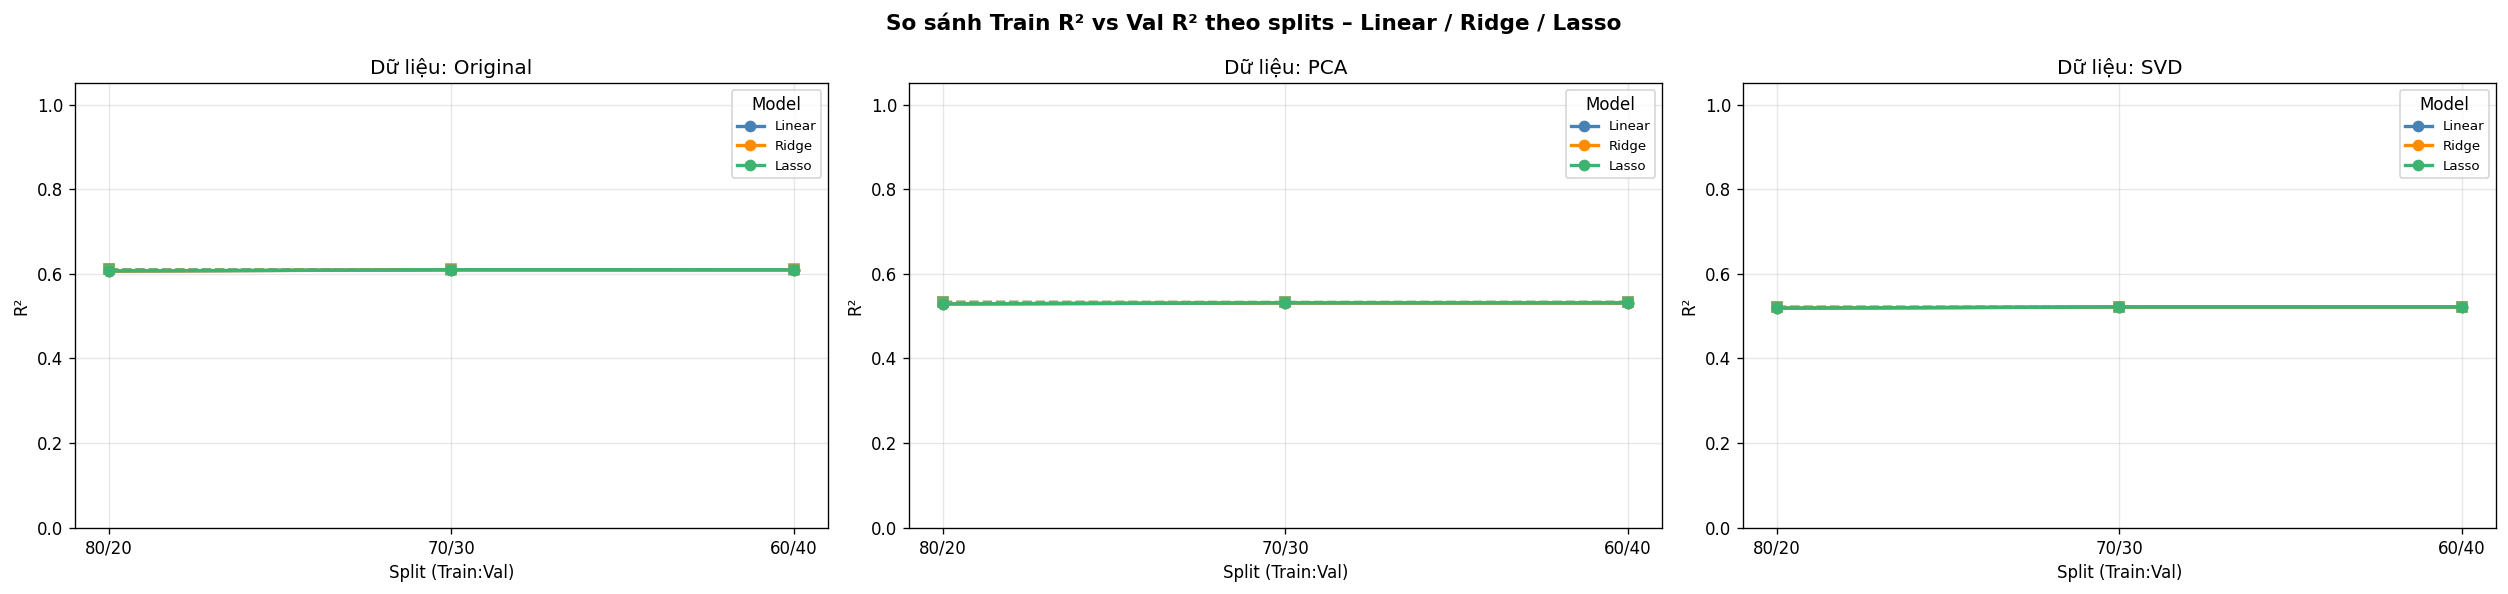

In [7]:
# 3.1 Line chart: Val R² theo splits – mỗi dòng = 1 model, mỗi subplot = 1 data type
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
split_order = ['80/20', '70/30', '60/40']
colors_model = {'Linear': 'steelblue', 'Ridge': 'darkorange', 'Lasso': 'mediumseagreen'}

fig, axes = plt.subplots(1, len(avail_dt), figsize=(7*len(avail_dt), 5))
if len(avail_dt) == 1: axes = [axes]
fig.suptitle('So sánh Train R² vs Val R² theo splits – Linear / Ridge / Lasso',
             fontsize=13, fontweight='bold')

for ax, dt in zip(axes, avail_dt):
    sub_dt = results_df[results_df['Data'] == dt]
    for mname in model_list:
        sub = sub_dt[sub_dt['Model'] == mname].set_index('Split').reindex(split_order)
        ax.plot(split_order, sub['Train_R2'], marker='s', linestyle='--',
                color=colors_model.get(mname, 'gray'), alpha=0.55, linewidth=1.5)
        ax.plot(split_order, sub['Val_R2'], marker='o',
                color=colors_model.get(mname, 'gray'), linewidth=2, label=mname)
    ax.set_title(f'Dữ liệu: {dt}')
    ax.set_xlabel('Split (Train:Val)')
    ax.set_ylabel('R²')
    ax.set_ylim(0, 1.05)
    ax.legend(title='Model', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_METRICS}/r2_line_comparison.png', bbox_inches='tight')
plt.show()


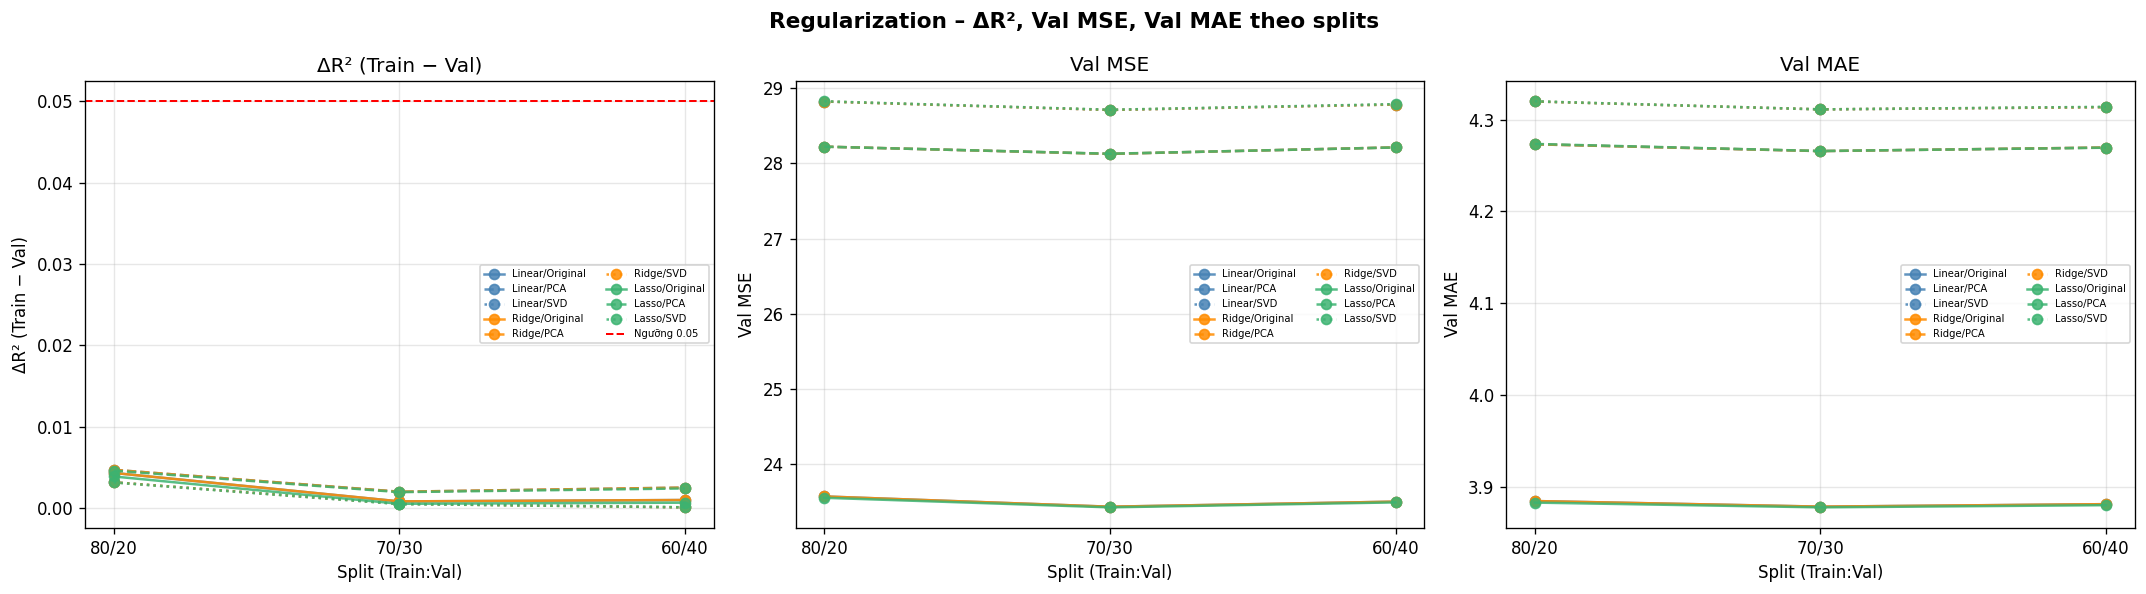

In [8]:
# 3.2 Line chart: ΔR², RMSE, MAE – tổng hợp 3 model x 3 data types
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
split_order = ['80/20', '70/30', '60/40']
colors_model = {'Linear': 'steelblue', 'Ridge': 'darkorange', 'Lasso': 'mediumseagreen'}
linestyles   = {'Original': '-', 'PCA': '--', 'SVD': ':'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regularization – ΔR², Val MSE, Val MAE theo splits', fontsize=13, fontweight='bold')

metrics_cfg = [
    ('Delta_R2', 'ΔR² (Train − Val)', axes[0], True),
    ('Val_MSE', 'Val MSE',           axes[1], False),
    ('Val_MAE',  'Val MAE',            axes[2], False),
]

for col, ylabel, ax, add_threshold in metrics_cfg:
    for mname in model_list:
        for dt in avail_dt:
            sub = results_df[(results_df['Model'] == mname) & (results_df['Data'] == dt)]
            sub = sub.set_index('Split').reindex(split_order)
            ax.plot(split_order, sub[col], marker='o', linewidth=1.5,
                    color=colors_model.get(mname, 'gray'),
                    linestyle=linestyles.get(dt, '-'),
                    alpha=0.85, label=f'{mname}/{dt}')
    if add_threshold:
        ax.axhline(0.05, color='red', linestyle='--', linewidth=1.2, label='Ngưỡng 0.05')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Split (Train:Val)')
    ax.set_title(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.savefig(f'{FIG_METRICS}/delta_mse_mae_line.png', bbox_inches='tight')
plt.show()


## 4. Phân tích Overfit – Heatmap ΔR²

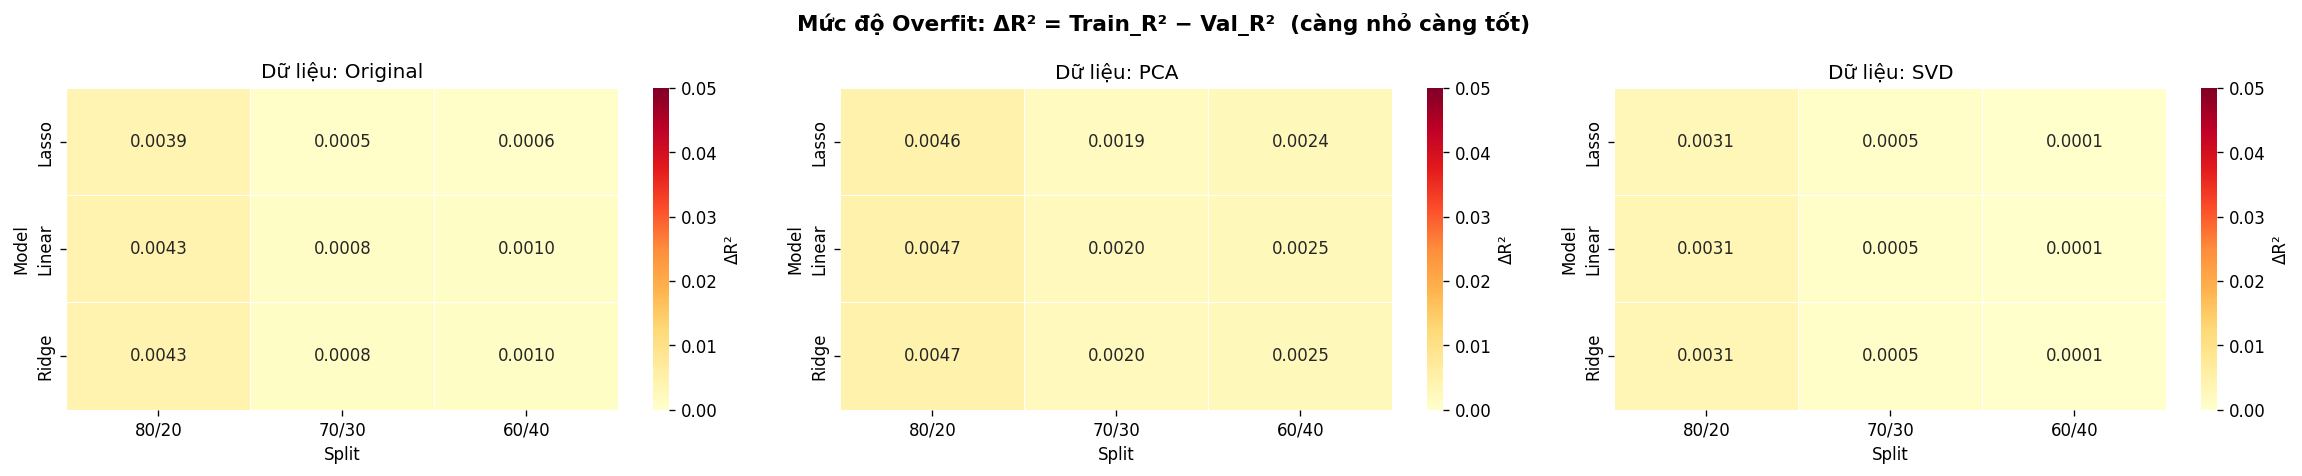

In [9]:
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
split_order_cols = ['80/20', '70/30', '60/40']

fig, axes = plt.subplots(1, len(avail_dt), figsize=(6.5*len(avail_dt), 4))
if len(avail_dt) == 1: axes = [axes]
fig.suptitle('Mức độ Overfit: ΔR² = Train_R² − Val_R²  (càng nhỏ càng tốt)',
             fontsize=13, fontweight='bold')

for ax, data_type in zip(axes, avail_dt):
    sub   = results_df[results_df['Data'] == data_type]
    pivot = sub.pivot_table(index='Model', columns='Split', values='Delta_R2')
    pivot = pivot[[s for s in split_order_cols if s in pivot.columns]]
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                linewidths=0.5, cbar_kws={'label': 'ΔR²'}, ax=ax,
                vmin=0, vmax=0.05)
    ax.set_title(f'Dữ liệu: {data_type}')
    ax.set_xlabel('Split')
    ax.set_ylabel('Model')

plt.tight_layout()
plt.savefig(f'{FIG_METRICS}/overfit_heatmap.png', bbox_inches='tight')
plt.show()


## 5. So sánh Original vs PCA vs SVD

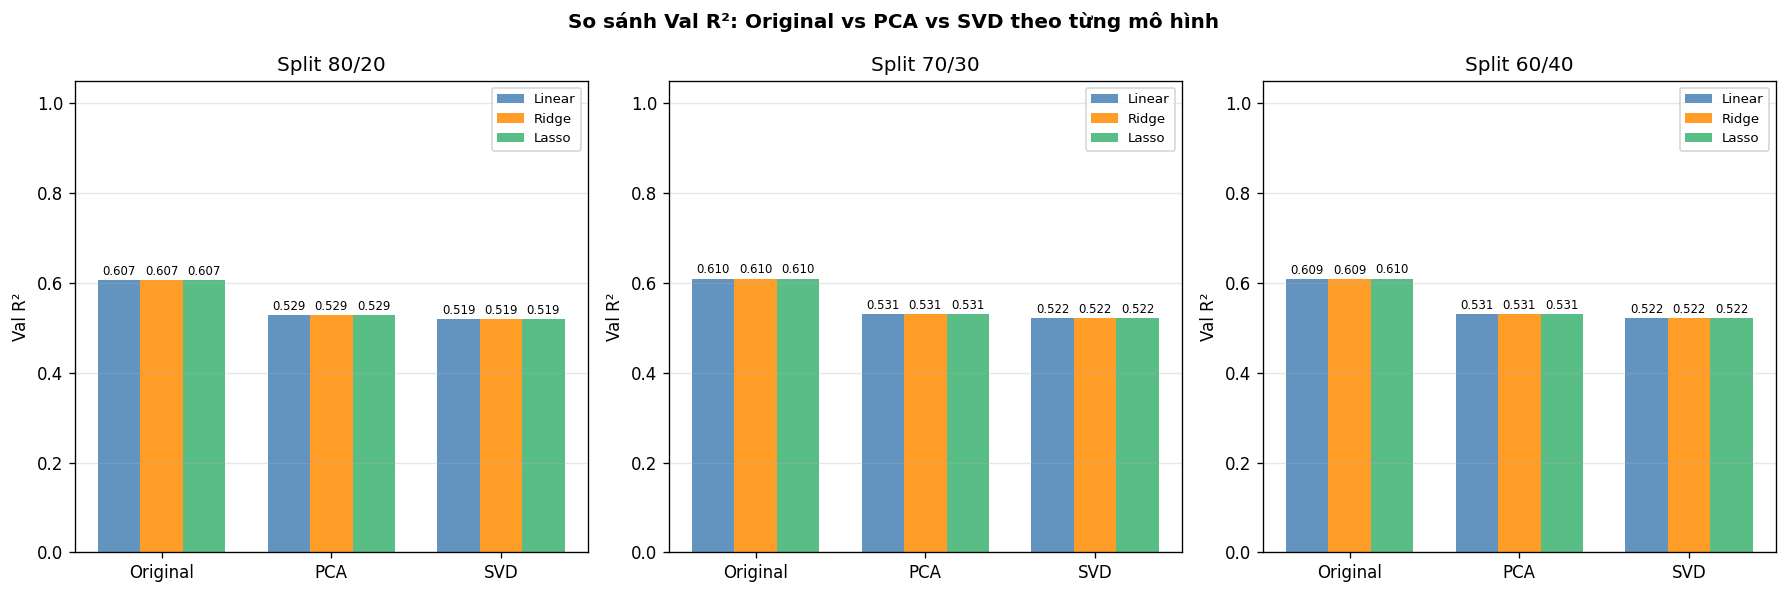

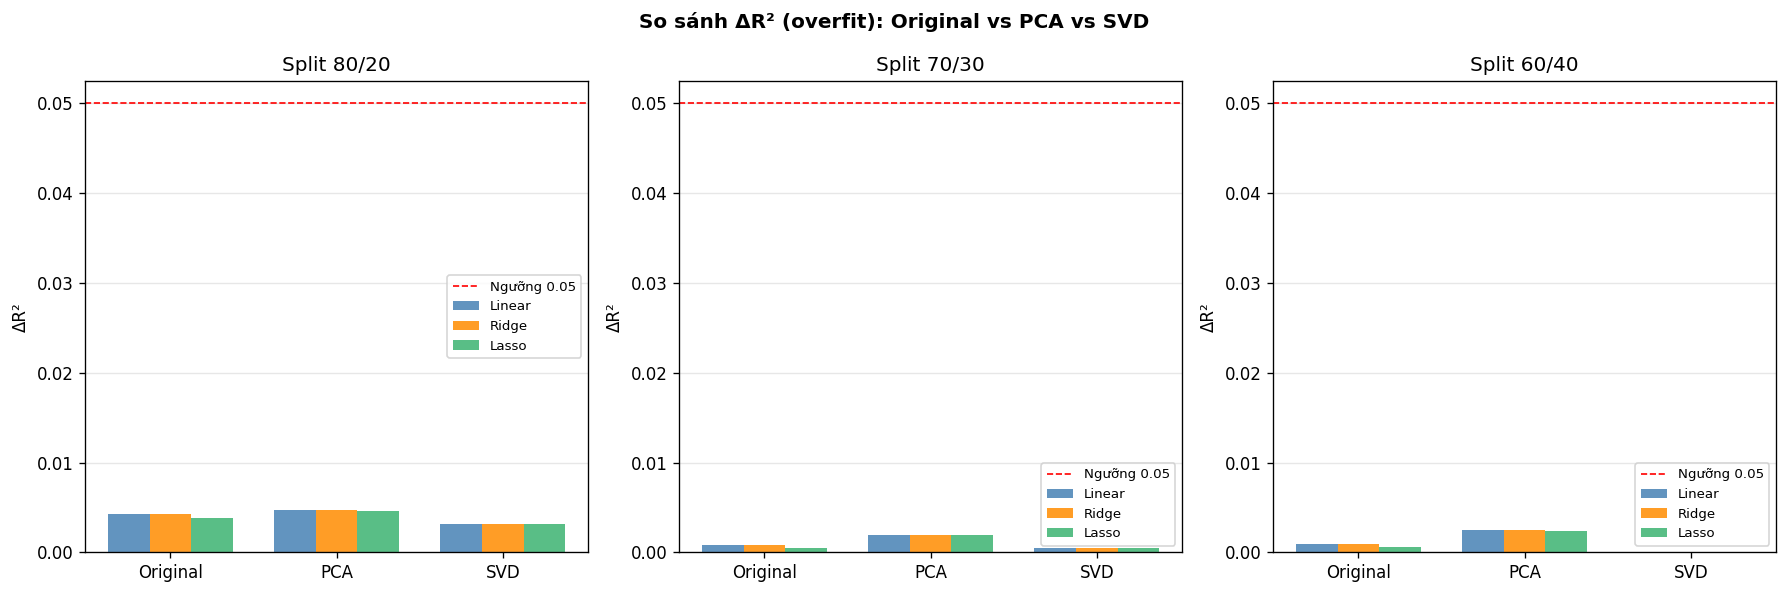

In [10]:
avail = results_df['Data'].unique()
dim_methods = [dt for dt in ['PCA', 'SVD'] if dt in avail]

if len(dim_methods) < 2:
    print('Chưa đủ dữ liệu để so sánh PCA và SVD (cần cả hai).')
else:
    split_order = ['80/20', '70/30', '60/40']
    colors_model = {'Linear': 'steelblue', 'Ridge': 'darkorange', 'Lasso': 'mediumseagreen'}
    dt_order = ['Original'] + dim_methods

    # Val R²: grouped by data type, x=splits, hue=model
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('So sánh Val R²: Original vs PCA vs SVD theo từng mô hình',
                 fontsize=12, fontweight='bold')

    for ax, split_label in zip(axes, split_order):
        sub = results_df[results_df['Split'] == split_label]
        x = np.arange(len(dt_order))
        w = 0.25
        for i, mname in enumerate(model_list):
            vals = [sub[(sub['Model'] == mname) & (sub['Data'] == dt)]['Val_R2'].values[0]
                    if len(sub[(sub['Model'] == mname) & (sub['Data'] == dt)]) > 0 else np.nan
                    for dt in dt_order]
            bars = ax.bar(x + i*w, vals, w, label=mname,
                          color=colors_model.get(mname, 'gray'), alpha=0.85)
            for bar in bars:
                if not np.isnan(bar.get_height()):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(x + w)
        ax.set_xticklabels(dt_order)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Val R²')
        ax.set_title(f'Split {split_label}')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIG_METRICS}/compare_pca_svd_r2.png', bbox_inches='tight')
    plt.show()

    # ΔR²: so sánh overfit
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('So sánh ΔR² (overfit): Original vs PCA vs SVD',
                 fontsize=12, fontweight='bold')

    for ax, split_label in zip(axes, split_order):
        sub = results_df[results_df['Split'] == split_label]
        x = np.arange(len(dt_order))
        w = 0.25
        for i, mname in enumerate(model_list):
            vals = [sub[(sub['Model'] == mname) & (sub['Data'] == dt)]['Delta_R2'].values[0]
                    if len(sub[(sub['Model'] == mname) & (sub['Data'] == dt)]) > 0 else np.nan
                    for dt in dt_order]
            ax.bar(x + i*w, vals, w, label=mname,
                   color=colors_model.get(mname, 'gray'), alpha=0.85)
        ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='Ngưỡng 0.05')
        ax.set_xticks(x + w)
        ax.set_xticklabels(dt_order)
        ax.set_ylabel('ΔR²')
        ax.set_title(f'Split {split_label}')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIG_METRICS}/compare_pca_svd_delta_r2.png', bbox_inches='tight')
    plt.show()


## 6. Biểu đồ tổng hợp kết quả các phương pháp hiệu chỉnh

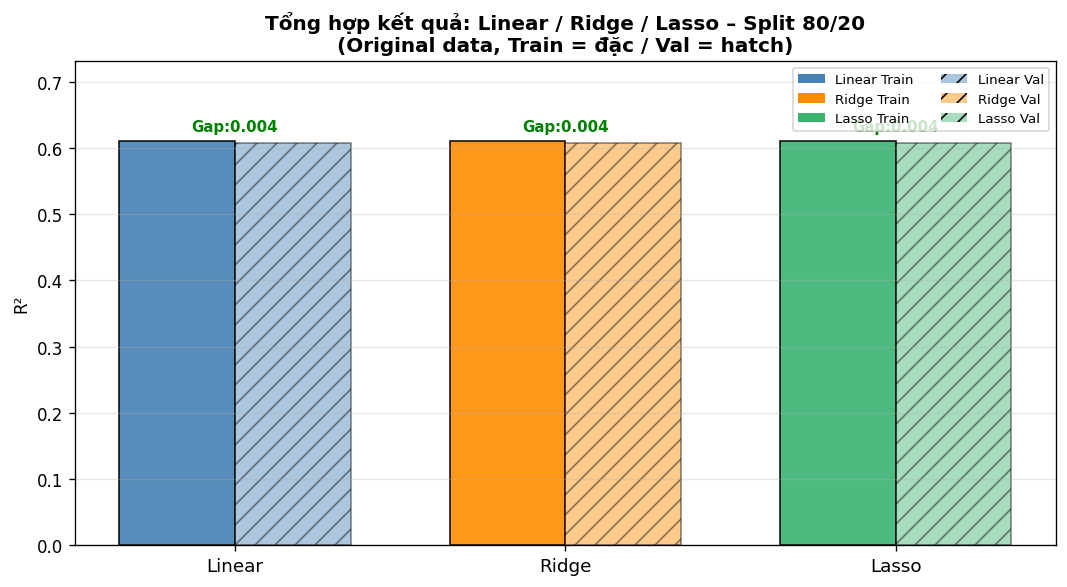

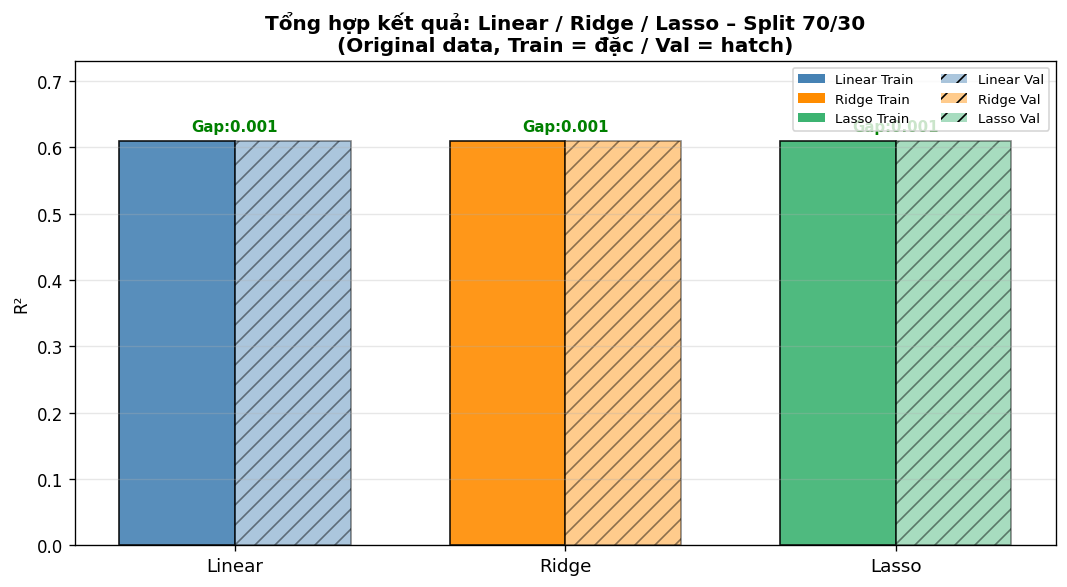

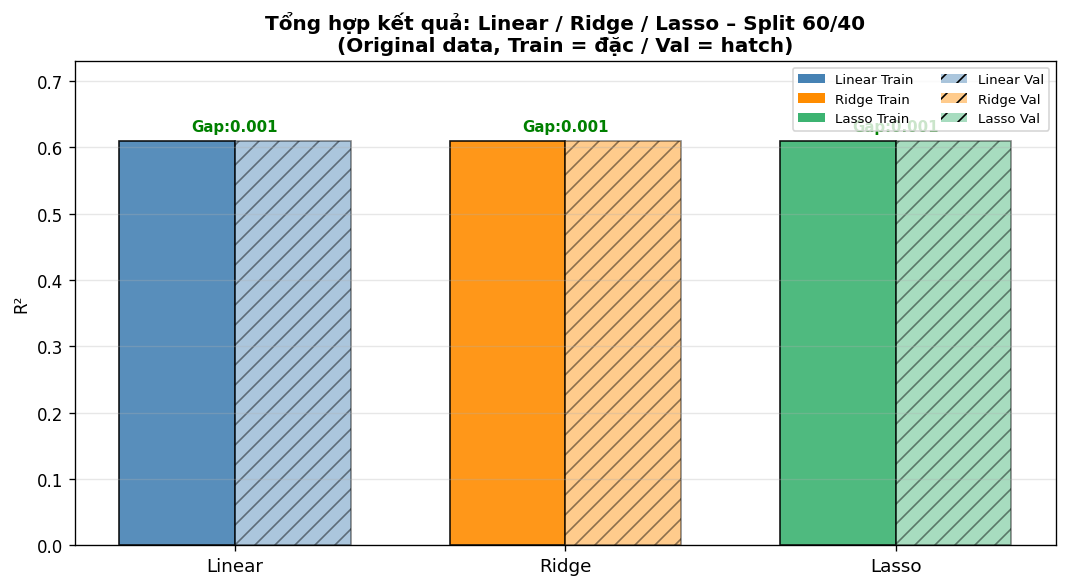

In [11]:
# Tổng hợp grouped bar Train vs Val R² cho mỗi split
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
split_order = ['80/20', '70/30', '60/40']
colors_model = {'Linear': 'steelblue', 'Ridge': 'darkorange', 'Lasso': 'mediumseagreen'}

for split_label in split_order:
    sub = results_df[(results_df['Split'] == split_label) &
                     (results_df['Data'] == 'Original')]
    if sub.empty:
        continue
    x = np.arange(len(sub))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (_, row) in enumerate(sub.iterrows()):
        c = colors_model.get(row['Model'], 'gray')
        ax.bar(i - width/2, row['Train_R2'], width, color=c, alpha=0.9,
               edgecolor='black')
        ax.bar(i + width/2, row['Val_R2'],   width, color=c, alpha=0.45,
               edgecolor='black', hatch='//')
        gap = row['Delta_R2']
        y_pos = max(row['Train_R2'], row['Val_R2']) + 0.015
        ax.text(i, y_pos, f"Gap:{gap:.3f}",
                ha='center', fontsize=9,
                color='red' if gap > 0.05 else 'green', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(sub['Model'], fontsize=11)
    ax.set_ylabel('R²')
    ax.set_ylim(0, max(sub['Train_R2'].max(), sub['Val_R2'].max()) + 0.12)
    ax.set_title(f'Tổng hợp kết quả: Linear / Ridge / Lasso – Split {split_label}\n'
                 f'(Original data, Train = đặc / Val = hatch)',
                 fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors_model.get(m,'gray'), label=f'{m} Train') for m in model_list] + \
                      [Patch(facecolor=colors_model.get(m,'gray'), alpha=0.45, hatch='//',
                             label=f'{m} Val') for m in model_list]
    ax.legend(handles=legend_elements, fontsize=8, ncol=2)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_METRICS}/summary_grouped_{split_label.replace("/","")}.png',
                bbox_inches='tight')
    plt.show()


## 7. Phân tích Regularization – Ảnh hưởng của α
### 7.1 Ridge & Lasso

In [12]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)
X_train, X_val = prepare_features(X_train_raw, X_val_raw, data_type='Original', random_state=SEED)

alphas_ridge = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10, 50, 100, 500, 1000]
alphas_lasso = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

ridge_rows, lasso_rows = [], []

for alpha in alphas_ridge:
    tr_m, vl_m, _, _ = evaluate_model(Ridge(alpha=alpha), X_train, X_val, y_train, y_val)
    ridge_rows.append({'alpha': alpha, 'Train_R2': tr_m['R2'], 'Val_R2': vl_m['R2'],
                       'Train_RMSE': tr_m['RMSE'], 'Val_RMSE': vl_m['RMSE'],
                       'Val_MSE': vl_m['MSE'],
                       'Delta_R2': tr_m['R2'] - vl_m['R2']})

for alpha in alphas_lasso:
    tr_m, vl_m, _, _ = evaluate_model(Lasso(alpha=alpha, max_iter=5000),
                                       X_train, X_val, y_train, y_val)
    lasso_rows.append({'alpha': alpha, 'Train_R2': tr_m['R2'], 'Val_R2': vl_m['R2'],
                       'Train_RMSE': tr_m['RMSE'], 'Val_RMSE': vl_m['RMSE'],
                       'Val_MSE': vl_m['MSE'],
                       'Delta_R2': tr_m['R2'] - vl_m['R2']})

ridge_df = pd.DataFrame(ridge_rows)
lasso_df = pd.DataFrame(lasso_rows)
print("Ridge – R² theo alpha:")
print(ridge_df[['alpha','Train_R2','Val_R2','Delta_R2','Val_MSE']].to_string(index=False))
print("\nLasso – R² theo alpha:")
print(lasso_df[['alpha','Train_R2','Val_R2','Delta_R2','Val_MSE']].to_string(index=False))

Ridge – R² theo alpha:
   alpha  Train_R2   Val_R2  Delta_R2  Val_MSE
   0.001  0.610303 0.609510  0.000793  23.4359
   0.010  0.610303 0.609509  0.000794  23.4359
   0.100  0.610303 0.609509  0.000794  23.4359
   0.500  0.610303 0.609508  0.000795  23.4360
   1.000  0.610303 0.609508  0.000795  23.4360
   5.000  0.610302 0.609507  0.000795  23.4361
  10.000  0.610302 0.609507  0.000795  23.4361
  50.000  0.610302 0.609507  0.000795  23.4360
 100.000  0.610301 0.609508  0.000793  23.4360
 500.000  0.610287 0.609499  0.000788  23.4365
1000.000  0.610246 0.609464  0.000782  23.4387

Lasso – R² theo alpha:
 alpha  Train_R2   Val_R2  Delta_R2  Val_MSE
0.0001  0.610301 0.609510  0.000791  23.4359
0.0010  0.610298 0.609541  0.000757  23.4340
0.0050  0.610244 0.609619  0.000625  23.4293
0.0100  0.610157 0.609657  0.000500  23.4271
0.0500  0.609490 0.609314  0.000176  23.4476
0.1000  0.608738 0.608700  0.000038  23.4845
0.5000  0.599844 0.600391 -0.000547  23.9832
1.0000  0.578556 0.579633 -0.

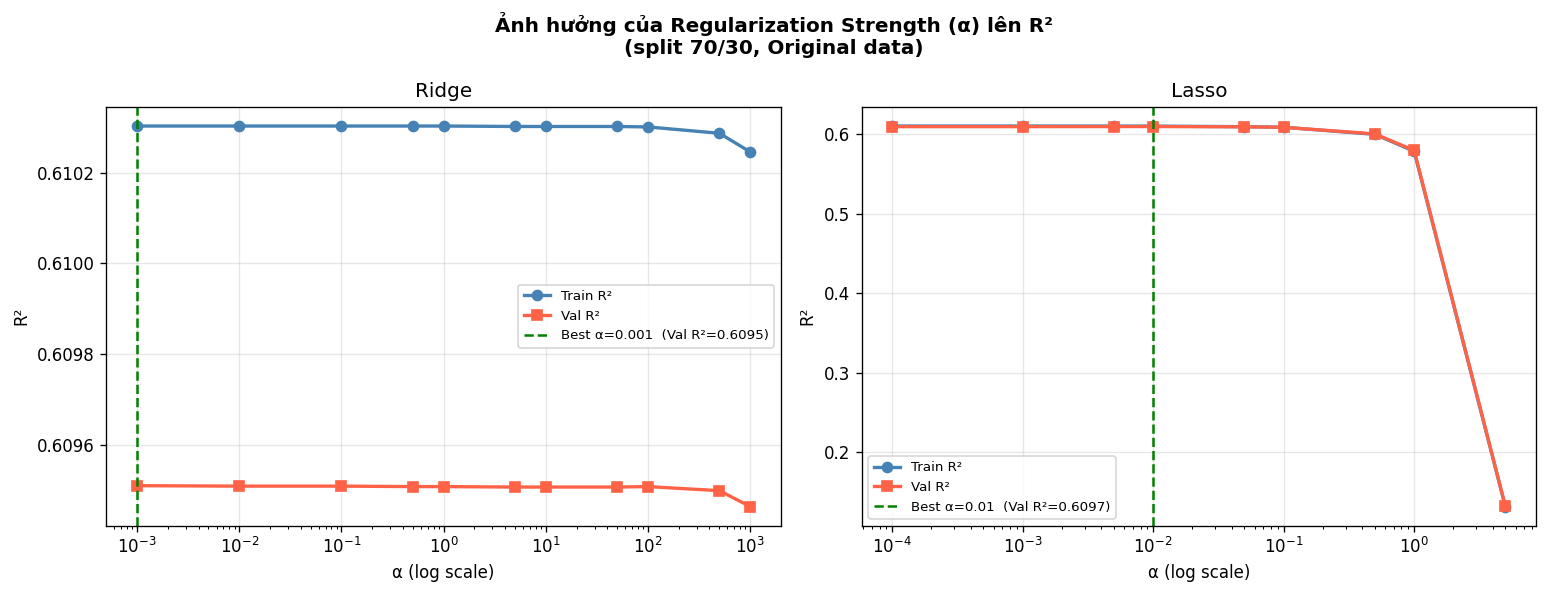

In [13]:
# Biểu đồ tác động của α lên R² – line chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ảnh hưởng của Regularization Strength (α) lên R²\n(split 70/30, Original data)',
             fontsize=12, fontweight='bold')

for ax, df, title in zip(axes, [ridge_df, lasso_df], ['Ridge', 'Lasso']):
    ax.semilogx(df['alpha'], df['Train_R2'], 'o-', color='steelblue',
                label='Train R²', linewidth=2)
    ax.semilogx(df['alpha'], df['Val_R2'], 's-', color='tomato',
                label='Val R²', linewidth=2)
    best_idx   = df['Val_R2'].idxmax()
    best_alpha = df.loc[best_idx, 'alpha']
    best_r2    = df.loc[best_idx, 'Val_R2']
    ax.axvline(best_alpha, color='green', linestyle='--', linewidth=1.5,
               label=f'Best α={best_alpha}  (Val R²={best_r2:.4f})')
    ax.set_xlabel('α (log scale)')
    ax.set_ylabel('R²')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_ALPHA}/ridge_lasso_alpha_r2.png', bbox_inches='tight')
plt.show()


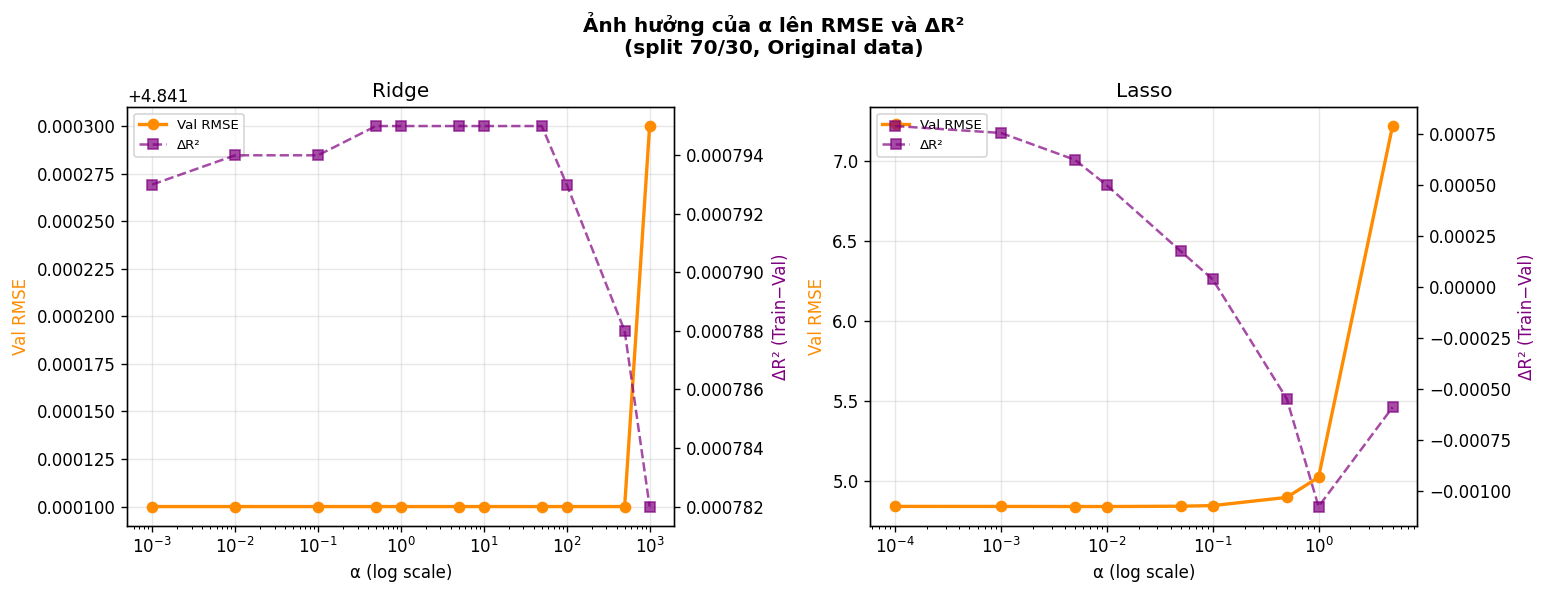

In [14]:
# Biểu đồ α lên MSE và ΔR² (dual axis)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ảnh hưởng của α lên RMSE và ΔR²\n(split 70/30, Original data)',
             fontsize=12, fontweight='bold')

for ax, df, title in zip(axes, [ridge_df, lasso_df], ['Ridge', 'Lasso']):
    ax2 = ax.twinx()
    ax.semilogx(df['alpha'], df['Val_RMSE'], 'o-', color='darkorange',
                label='Val RMSE', linewidth=2)
    ax2.semilogx(df['alpha'], df['Delta_R2'], 's--', color='purple',
                 label='ΔR²', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('α (log scale)')
    ax.set_ylabel('Val RMSE', color='darkorange')
    ax2.set_ylabel('ΔR² (Train−Val)', color='purple')
    ax.set_title(title)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_ALPHA}/ridge_lasso_alpha_rmse_delta.png', bbox_inches='tight')
plt.show()


### 7.2 Lasso – Hệ số hồi quy theo α (regularization path)

Features với hệ số ≠ 0: 42 / 86
Features bị zeroed out: 44


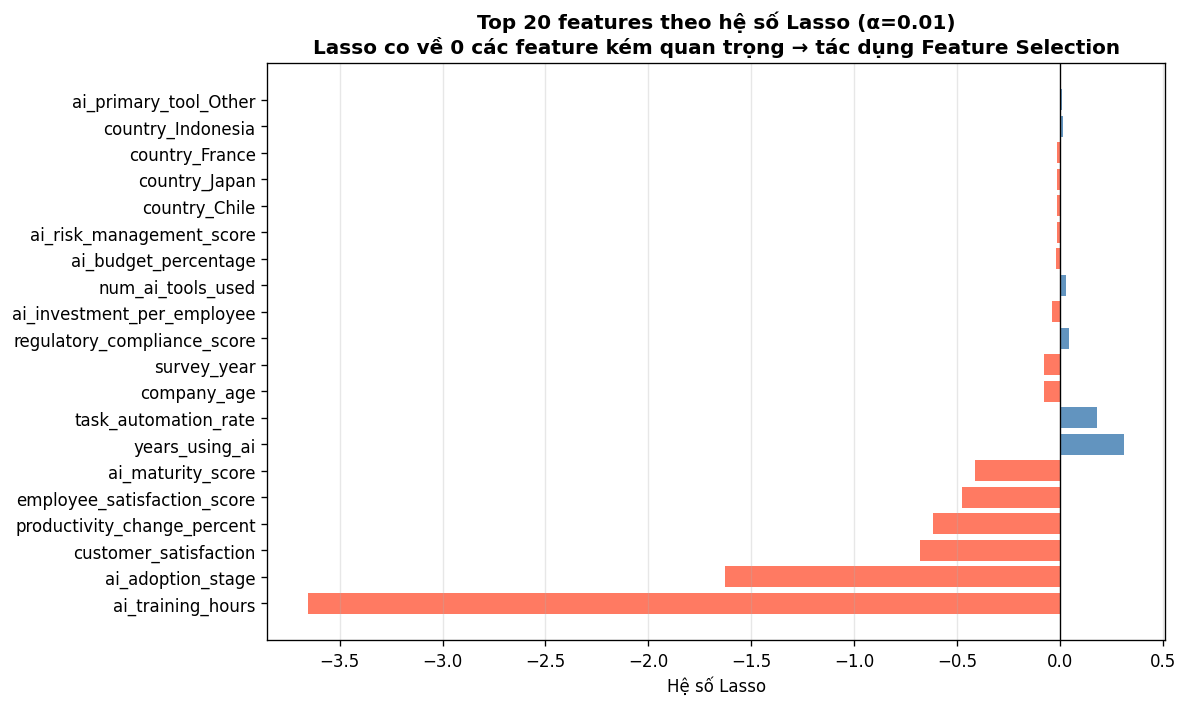

In [15]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)
X_train, X_val = prepare_features(X_train_raw, X_val_raw, data_type='Original', random_state=SEED)

lasso_best = Lasso(alpha=0.01, max_iter=5000)
lasso_best.fit(X_train, y_train)

coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lasso_best.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
nonzero = (coef_df['Coefficient'] != 0).sum()
zeroed  = (coef_df['Coefficient'] == 0).sum()
print(f"Features với hệ số ≠ 0: {nonzero} / {len(coef_df)}")
print(f"Features bị zeroed out: {zeroed}")

top20 = coef_df.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['tomato' if c < 0 else 'steelblue' for c in top20['Coefficient']]
ax.barh(top20['Feature'], top20['Coefficient'], color=colors_bar, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Hệ số Lasso')
ax.set_title('Top 20 features theo hệ số Lasso (α=0.01)\n'
             'Lasso co về 0 các feature kém quan trọng → tác dụng Feature Selection',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_ALPHA}/lasso_coefficients.png', bbox_inches='tight')
plt.show()

## 8. Phân tích phần dư – 1.4(b)
### 8.1 Load dữ liệu gốc split 7:3, chạy 3 mô hình

In [16]:
import scipy.stats as stats

# Dùng split 7:3, Original data, 3 mô hình
residuals_73 = {}

X_train_73_raw, X_val_73_raw, y_train_73, y_val_73 = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)
X_train_73, X_val_73 = prepare_features(
    X_train_73_raw,
    X_val_73_raw,
    data_type='Original',
    random_state=SEED
)

for model_name, model_cfg in model_configs:
    m = copy.deepcopy(model_cfg)
    tr_m, vl_m, y_pred, resid = evaluate_model(m, X_train_73, X_val_73, y_train_73, y_val_73)
    residuals_73[model_name] = {
        'residuals': resid,
        'y_pred': y_pred,
        'y_val': y_val_73,
        'X_val': X_val_73_raw.copy().reset_index(drop=True),
        'X_val_model': X_val_73
    }
    print(f"[{model_name}] Train R²={tr_m['R2']:.4f}  Val R²={vl_m['R2']:.4f}  MSE={vl_m['MSE']:.4f}")

[Linear] Train R²=0.6103  Val R²=0.6095  MSE=23.4359
[Ridge] Train R²=0.6103  Val R²=0.6095  MSE=23.4360
[Lasso] Train R²=0.6102  Val R²=0.6097  MSE=23.4271


### 8.2 Phần dư vs Dự đoán, Phần dư vs Thực tế, Thực tế vs Dự đoán

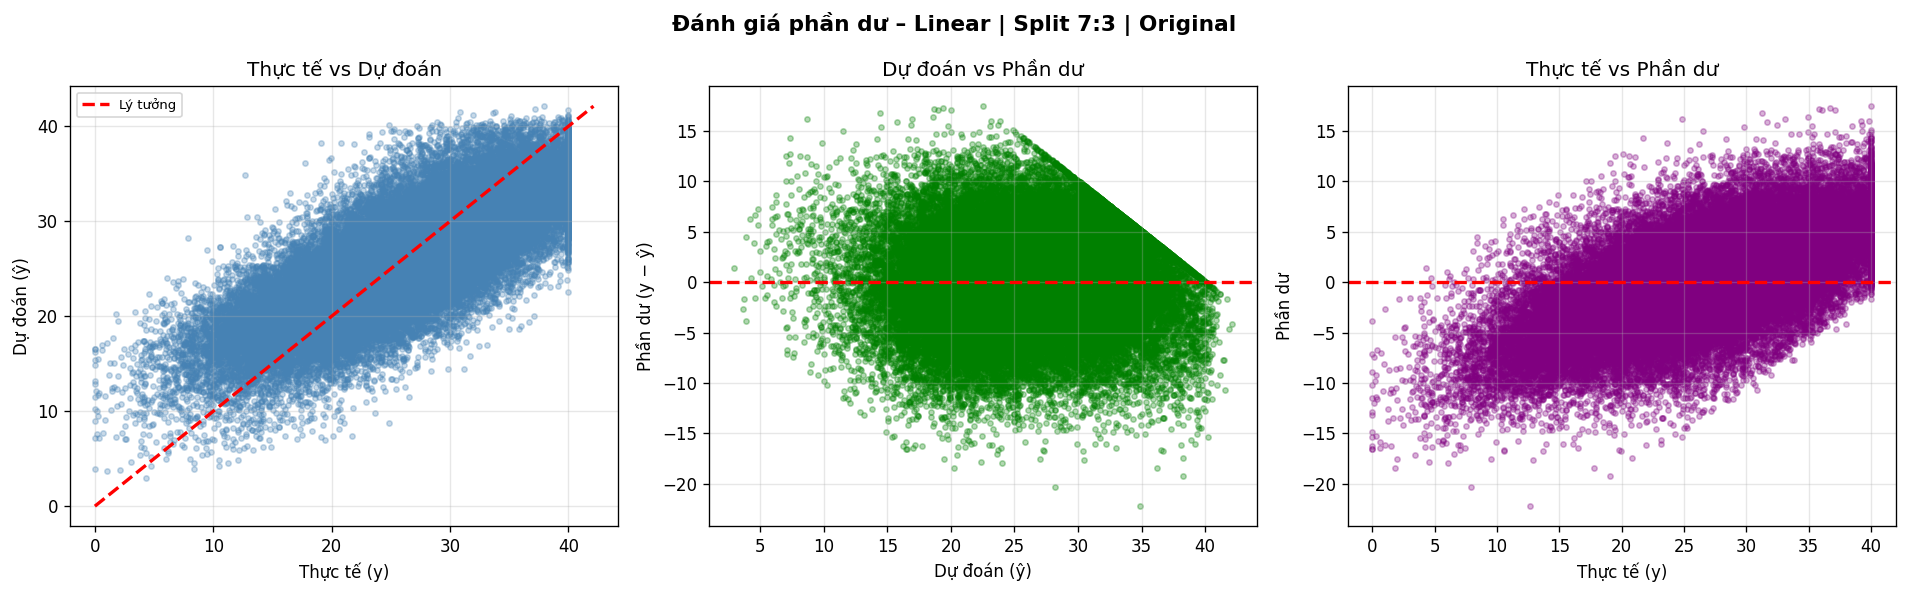

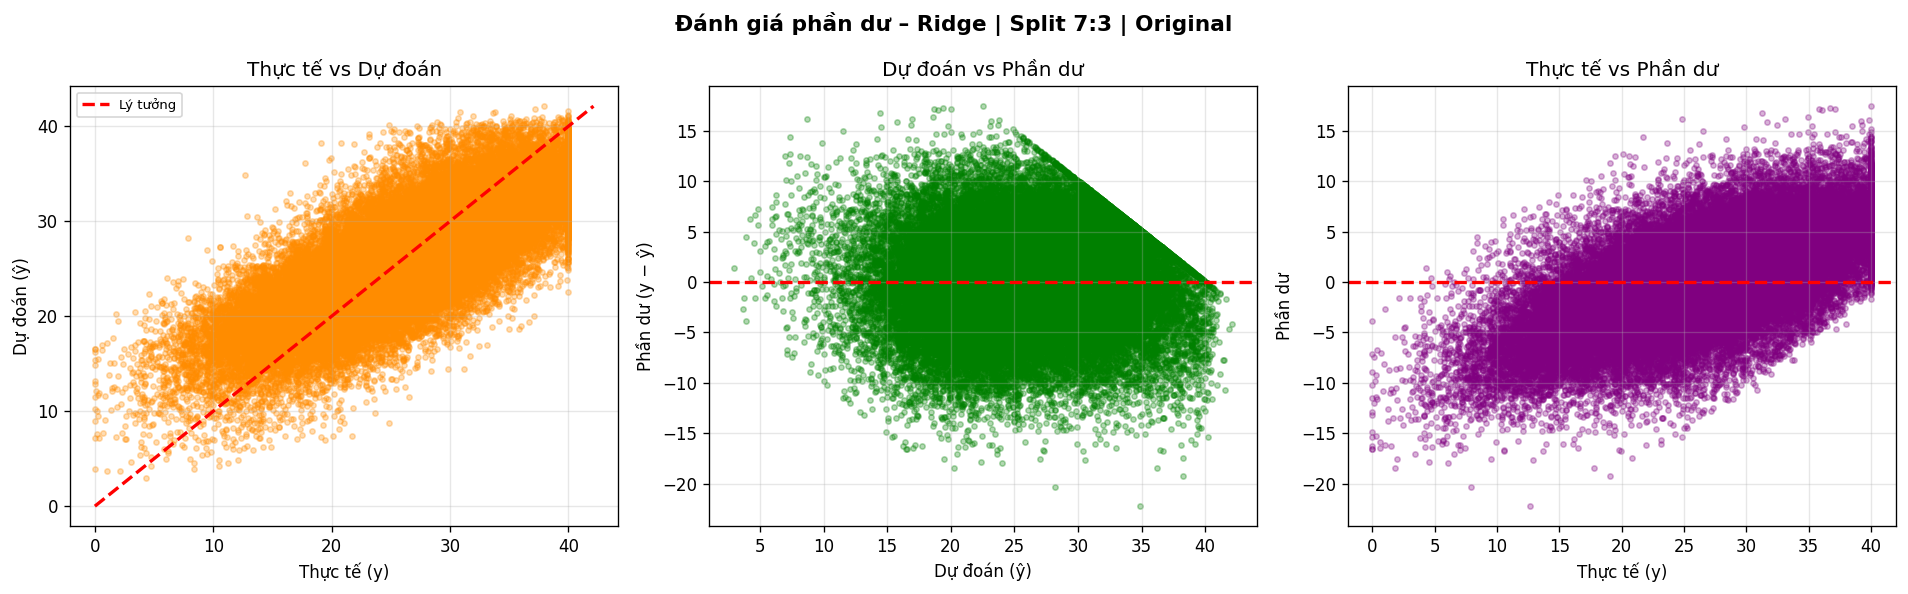

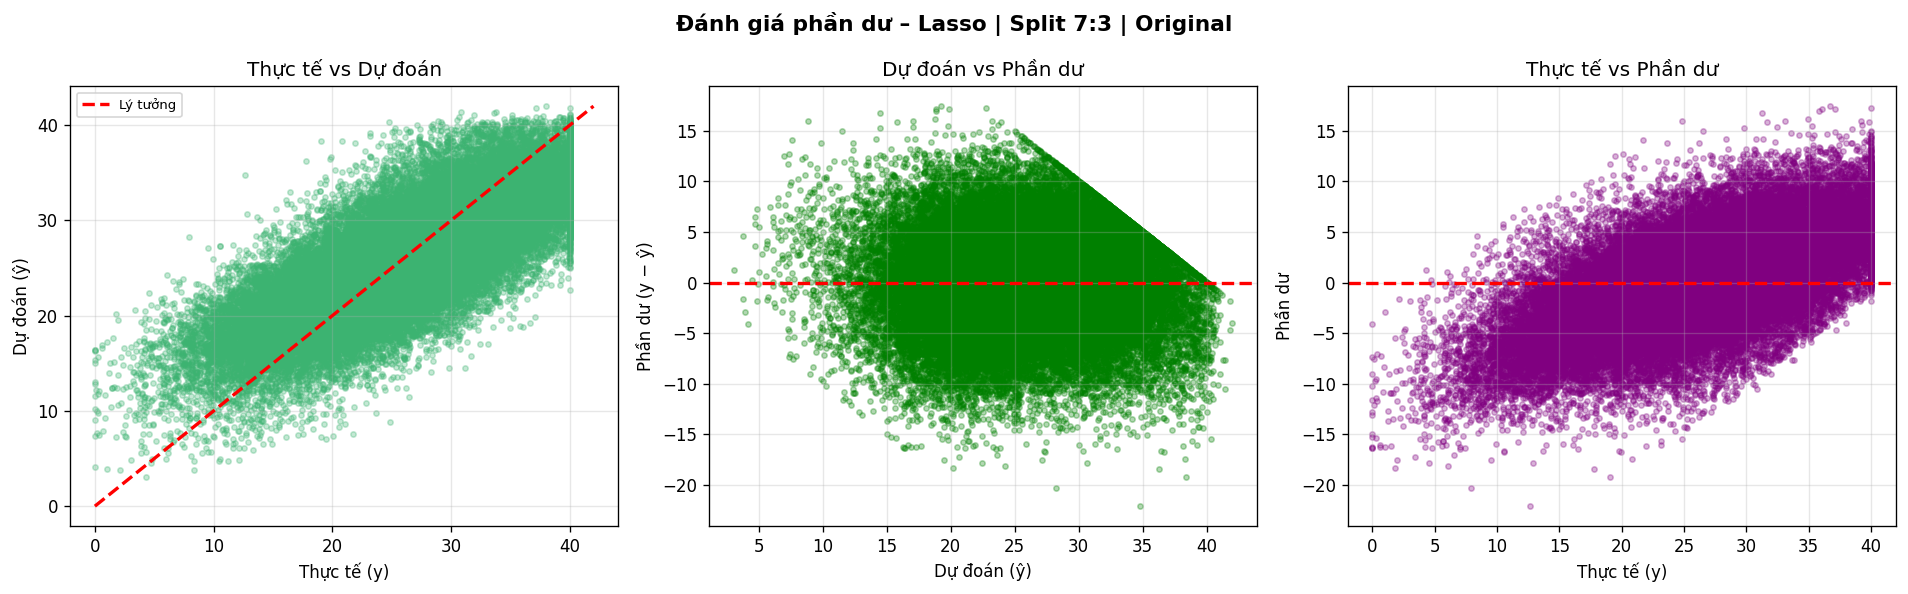

In [17]:
colors_model_73 = {'Linear': 'steelblue', 'Ridge': 'darkorange', 'Lasso': 'mediumseagreen'}

for mname in [k for k in ['Linear', 'Ridge', 'Lasso'] if k in residuals_73]:
    store = residuals_73[mname]
    ya    = store['y_val']
    yp    = store['y_pred']
    resid = store['residuals']
    color = colors_model_73.get(mname, 'steelblue')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Thực tế vs Dự đoán
    axes[0].scatter(ya, yp, alpha=0.3, s=10, color=color)
    mn, mx = min(ya.min(), yp.min()), max(ya.max(), yp.max())
    axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Lý tưởng')
    axes[0].set_title('Thực tế vs Dự đoán')
    axes[0].set_xlabel('Thực tế (y)')
    axes[0].set_ylabel('Dự đoán (ŷ)')
    axes[0].legend(fontsize=8)

    # Dự đoán vs Phần dư
    axes[1].scatter(yp, resid, alpha=0.3, s=10, color='green')
    axes[1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1].set_title('Dự đoán vs Phần dư')
    axes[1].set_xlabel('Dự đoán (ŷ)')
    axes[1].set_ylabel('Phần dư (y − ŷ)')

    # Thực tế vs Phần dư
    axes[2].scatter(ya, resid, alpha=0.3, s=10, color='purple')
    axes[2].axhline(0, color='r', linestyle='--', lw=2)
    axes[2].set_title('Thực tế vs Phần dư')
    axes[2].set_xlabel('Thực tế (y)')
    axes[2].set_ylabel('Phần dư')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Đánh giá phần dư – {mname} | Split 7:3 | Original',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{FIG_RESID}/residual_scatter_{mname.lower()}.png', bbox_inches='tight')
    plt.show()


### 8.3 Phân phối phần dư 

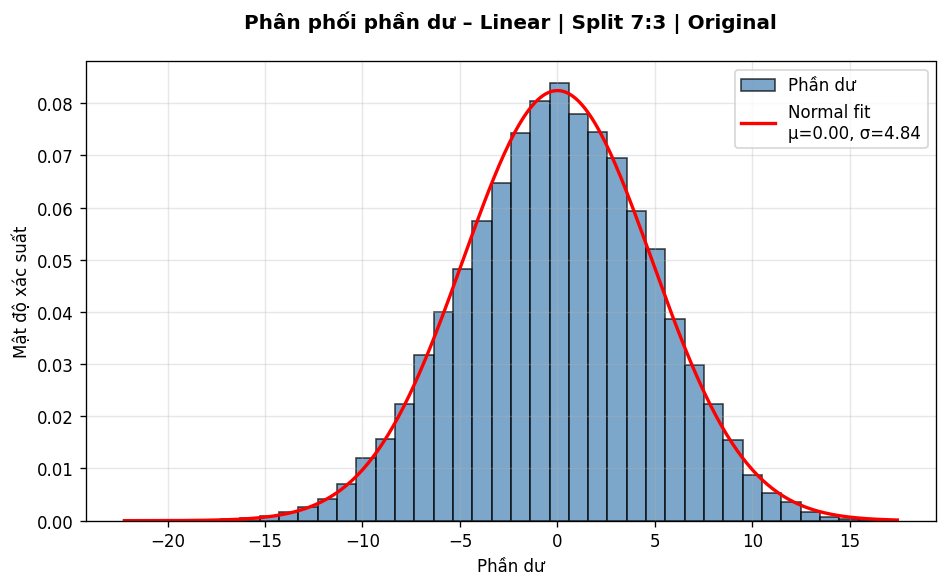

[Linear] Mean=0.0020  Std=4.8411  Skew=-0.0946  Kurt=-0.0845


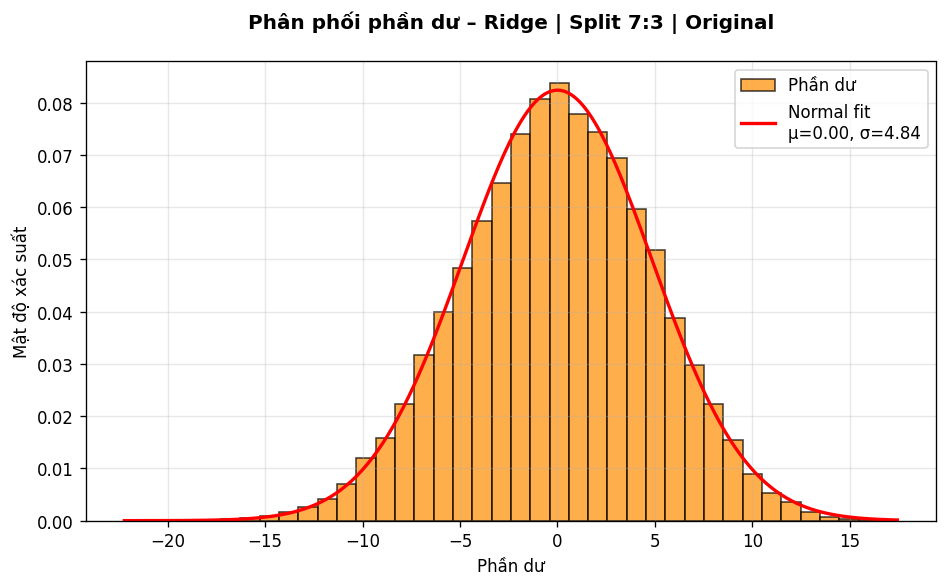

[Ridge] Mean=0.0019  Std=4.8411  Skew=-0.0946  Kurt=-0.0844


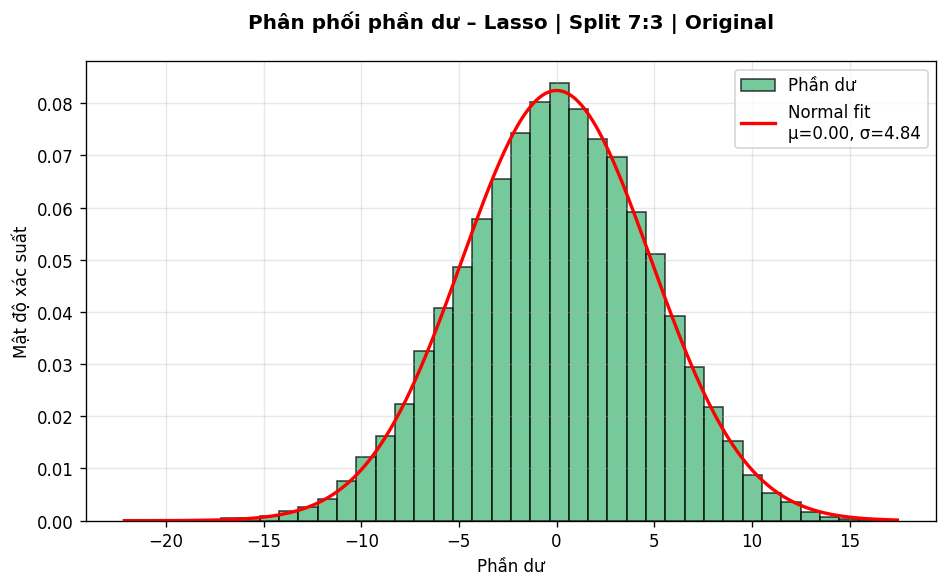

[Lasso] Mean=0.0011  Std=4.8402  Skew=-0.0959  Kurt=-0.0843


In [18]:
for mname in [k for k in ['Linear', 'Ridge', 'Lasso'] if k in residuals_73]:
    resid = residuals_73[mname]['residuals']
    color = colors_model_73.get(mname, 'steelblue')
    mu, sigma = resid.mean(), resid.std()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(resid, bins=40, color=color, edgecolor='black', alpha=0.7,
            density=True, label='Phần dư')

    x_plot = np.linspace(resid.min(), resid.max(), 300)
    ax.plot(x_plot, stats.norm.pdf(x_plot, mu, sigma),
            'r-', lw=2, label=f'Normal fit\nμ={mu:.2f}, σ={sigma:.2f}')

    

    ax.set_title(f'Phân phối phần dư – {mname} | Split 7:3 | Original\n',
                 fontweight='bold')
    ax.set_xlabel('Phần dư')
    ax.set_ylabel('Mật độ xác suất')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_RESID}/residual_dist_{mname.lower()}.png', bbox_inches='tight')
    plt.show()

    print(f"[{mname}] Mean={mu:.4f}  Std={sigma:.4f}  "
          f"Skew={float(pd.Series(resid).skew()):.4f}  "
          f"Kurt={float(pd.Series(resid).kurtosis()):.4f}")

### 8.4 Q-Q Plot phần dư

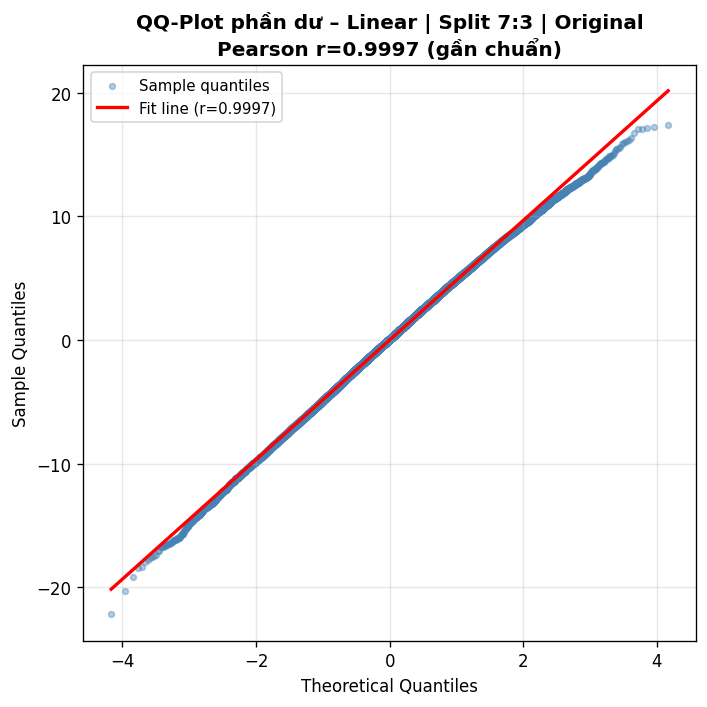

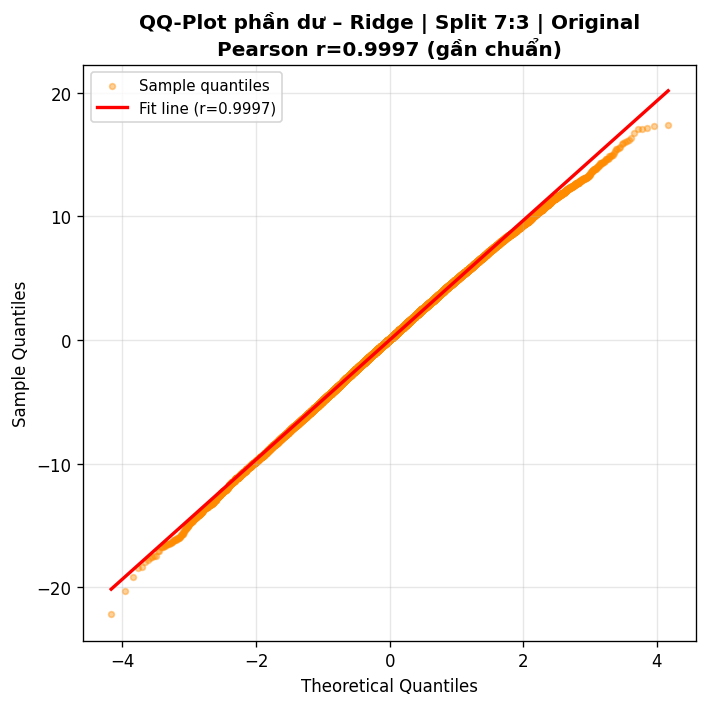

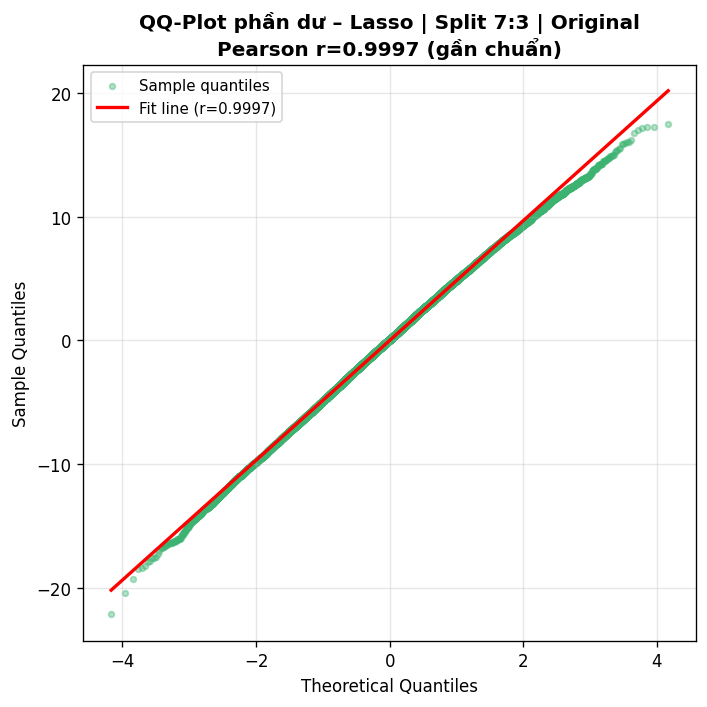

In [19]:
for mname in [k for k in ['Linear', 'Ridge', 'Lasso'] if k in residuals_73]:
    resid = residuals_73[mname]['residuals']
    color = colors_model_73.get(mname, 'steelblue')

    fig, ax = plt.subplots(figsize=(6, 6))
    (osm, osr), (slope, intercept, r_val) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, alpha=0.4, s=12, color=color, label='Sample quantiles')
    ax.plot(np.array(osm), slope * np.array(osm) + intercept,
            'r-', lw=2, label=f'Fit line (r={r_val:.4f})')
    verdict = 'gần chuẩn' if r_val > 0.99 else 'lệch khỏi chuẩn'
    ax.set_title(f'QQ-Plot phần dư – {mname} | Split 7:3 | Original\n'
                 f'Pearson r={r_val:.4f} ({verdict})', fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_RESID}/qqplot_{mname.lower()}.png', bbox_inches='tight')
    plt.show()


### 8.5 Tương quan phần dư với features (dữ liệu gốc, split 7:3)

Biến số (numeric/ordinal): 24 cột
Biến còn lại (cate/one-hot/chu kì): 62 cột


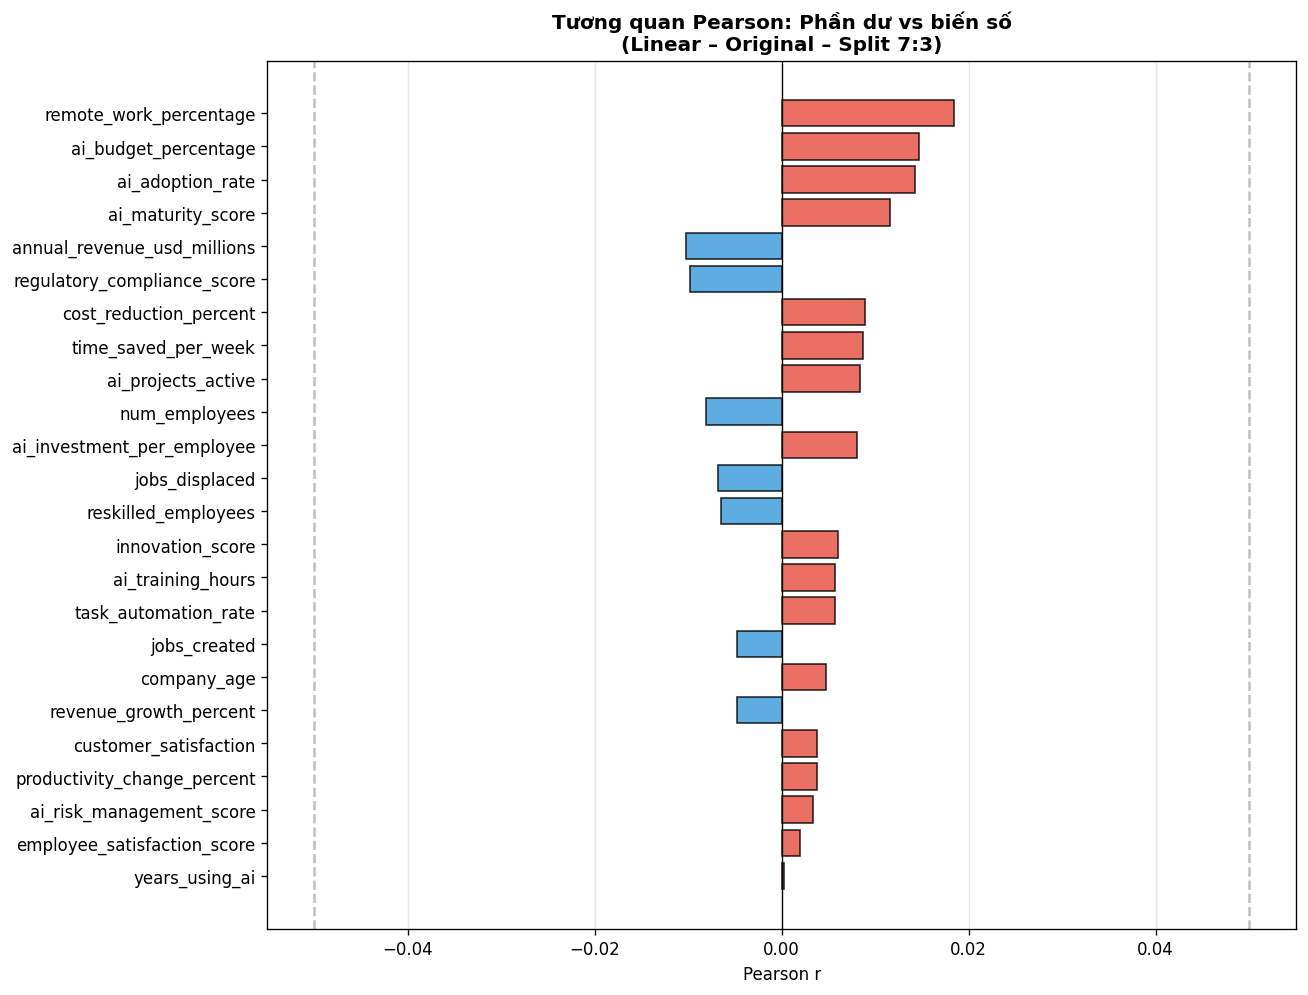

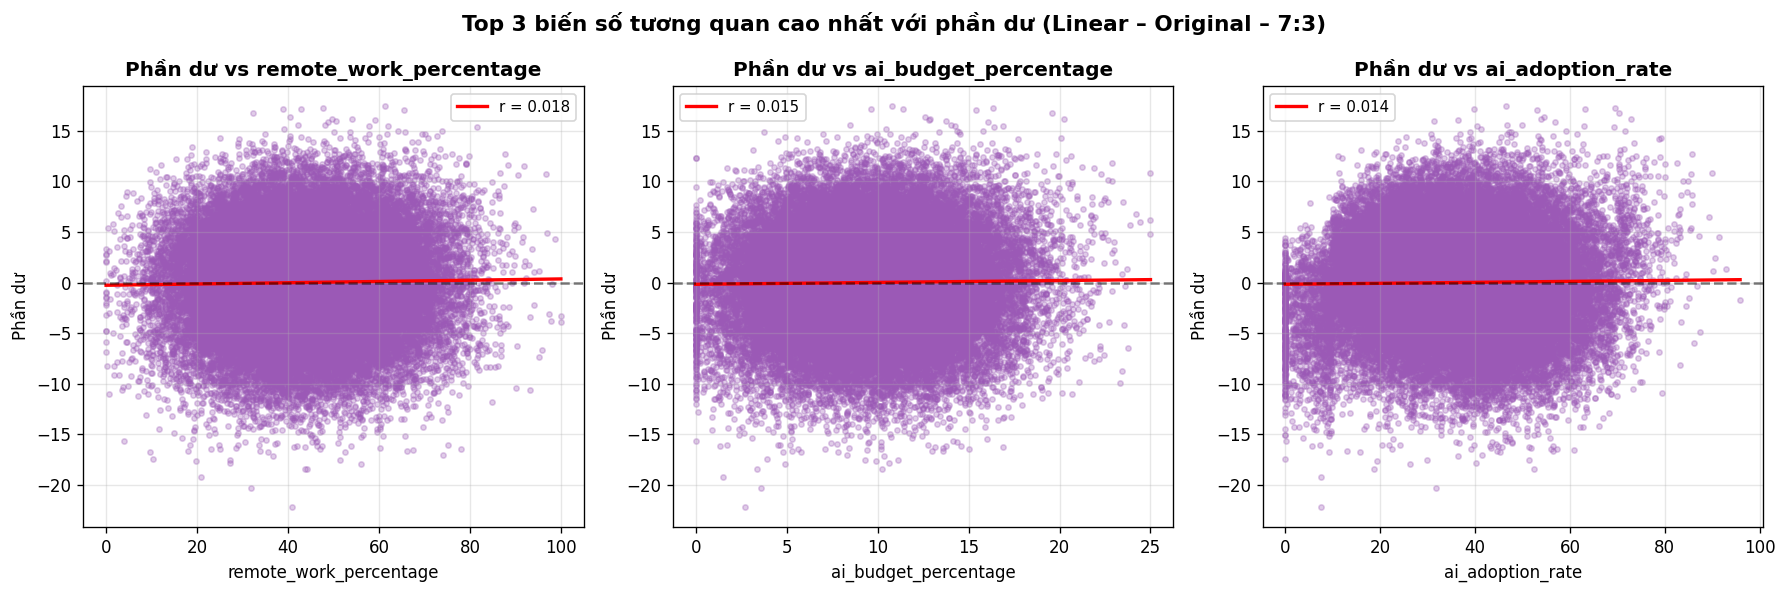

In [20]:
if 'Linear' in residuals_73:
    X_val_73  = residuals_73['Linear']['X_val'].copy().reset_index(drop=True)
    resid_73  = residuals_73['Linear']['residuals']

    # Tách biến số vs biến còn lại (heuristic: nunique > 10)
    numeric_cols = [c for c in X_val_73.columns if X_val_73[c].nunique() > 10]
    other_cols   = [c for c in X_val_73.columns if c not in numeric_cols]
    print(f"Biến số (numeric/ordinal): {len(numeric_cols)} cột")
    print(f"Biến còn lại (cate/one-hot/chu kì): {len(other_cols)} cột")

    # Pearson correlation
    if numeric_cols:
        corr_vals = {col: stats.pearsonr(X_val_73[col], resid_73)[0]
                     for col in numeric_cols}
        corr_series = pd.Series(corr_vals).sort_values(key=abs, ascending=False)

        fig, ax = plt.subplots(figsize=(11, max(5, len(numeric_cols)*0.35)))
        colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in corr_series.values]
        ax.barh(corr_series.index[::-1], corr_series.values[::-1],
                color=colors_bar[::-1], edgecolor='black', alpha=0.8)
        ax.axvline(0,     color='black', linewidth=0.8)
        ax.axvline( 0.05, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(-0.05, color='gray', linestyle='--', alpha=0.5)
        ax.set_title('Tương quan Pearson: Phần dư vs biến số\n(Linear – Original – Split 7:3)',
                     fontweight='bold')
        ax.set_xlabel('Pearson r')
        ax.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{FIG_RESID}/corr_numeric_residual_linear.png', bbox_inches='tight')
        plt.show()

        # Scatter top 3 biến
        top3 = corr_series.head(3).index.tolist()
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for i, col in enumerate(top3):
            x_vals = X_val_73[col].values
            axes[i].scatter(x_vals, resid_73, alpha=0.3, s=10, color='#9b59b6')
            m_fit, b_fit = np.polyfit(x_vals, resid_73, 1)
            xs = np.linspace(x_vals.min(), x_vals.max(), 200)
            axes[i].plot(xs, m_fit * xs + b_fit, 'r-', lw=2,
                         label=f'r = {corr_series[col]:.3f}')
            axes[i].axhline(0, color='black', linestyle='--', alpha=0.5)
            axes[i].set_title(f'Phần dư vs {col}', fontweight='bold')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Phần dư')
            axes[i].legend(fontsize=9)
            axes[i].grid(True, alpha=0.3)
        plt.suptitle('Top 3 biến số tương quan cao nhất với phần dư (Linear – Original – 7:3)',
                     fontweight='bold', fontsize=13)
        plt.tight_layout()
        plt.savefig(f'{FIG_RESID}/top3_scatter_residual_linear.png', bbox_inches='tight')
        plt.show()


### 8.6 Boxplot phần dư theo biến categorical / chu kỳ

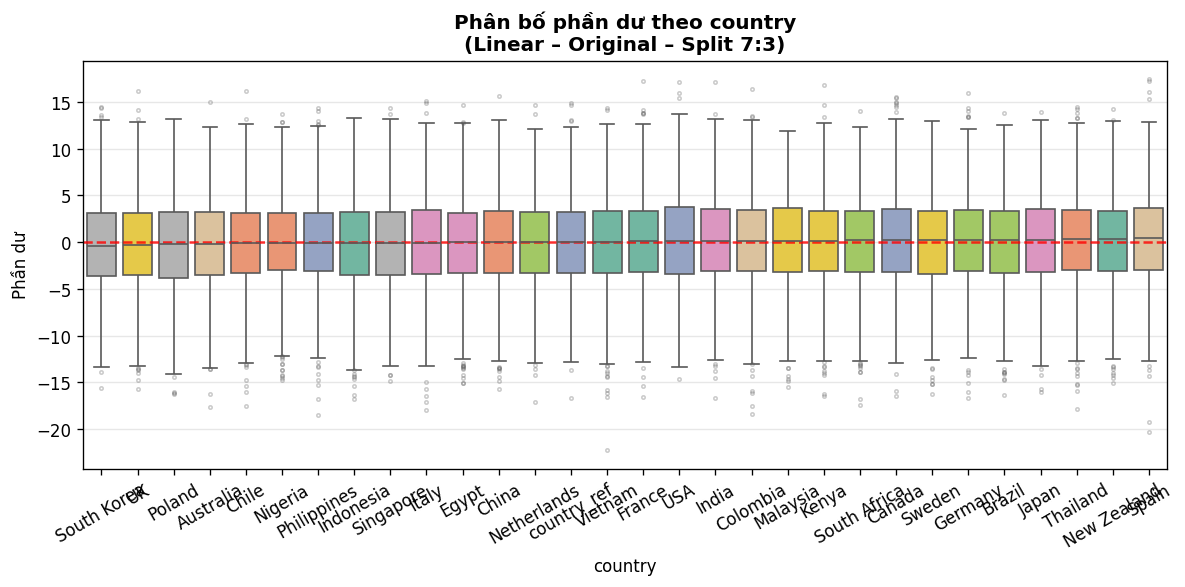

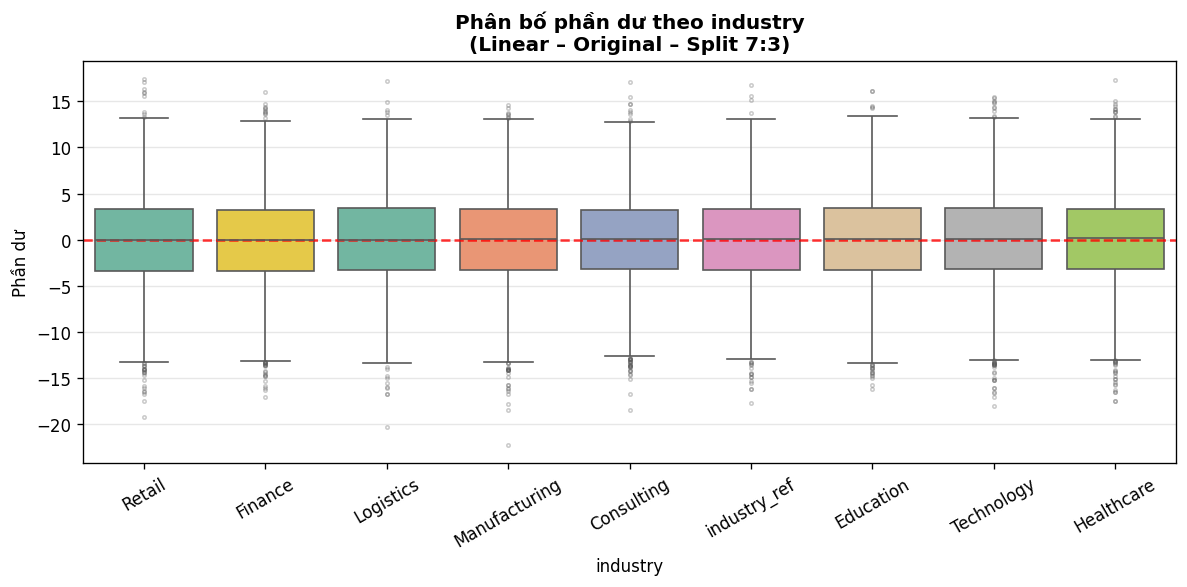

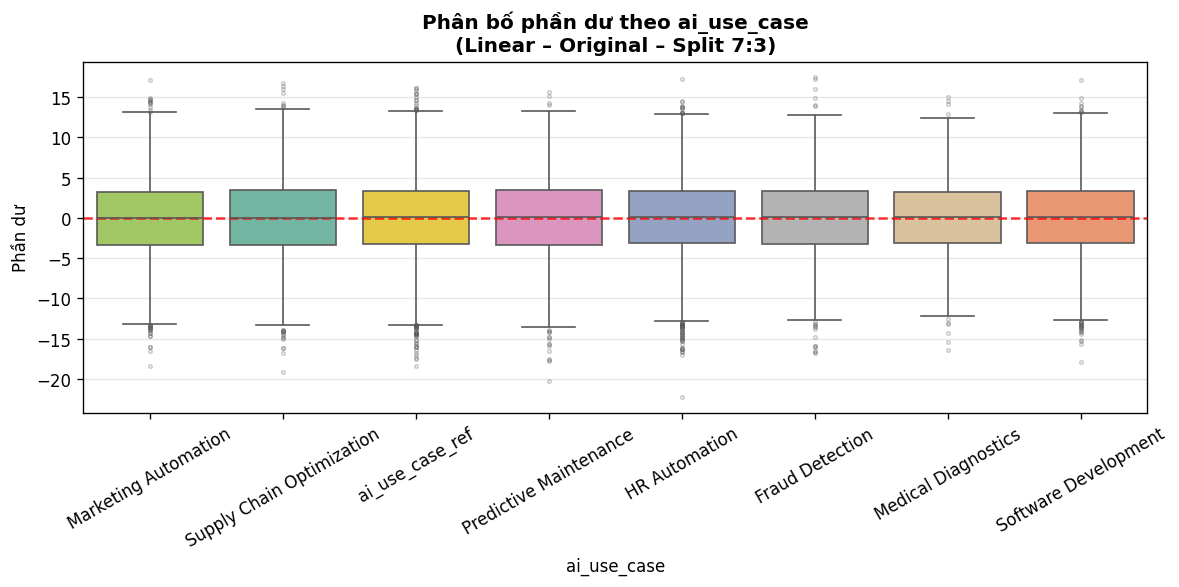

In [21]:
if 'Linear' in residuals_73 and other_cols:

    def decode_onehot(X_df, prefix):
        cols = [c for c in X_df.columns if c.startswith(prefix + '_')]
        if not cols:
            return None
        decoded = X_df[cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)
        row_sum = X_df[cols].sum(axis=1)
        decoded[row_sum == 0] = f'{prefix}_ref'
        return decoded

    prefixes_found = {}
    for col in other_cols:
        if '_' in col:
            prefix = '_'.join(col.split('_')[:-1])
            prefixes_found[prefix] = prefixes_found.get(prefix, 0) + 1

    top_prefixes = sorted(prefixes_found, key=lambda p: prefixes_found[p], reverse=True)[:3]

    chosen_cats = {}
    for pref in top_prefixes:
        decoded = decode_onehot(X_val_73, pref)
        if decoded is not None:
            chosen_cats[pref] = decoded

    if not chosen_cats:
        binary_cols = [c for c in other_cols if X_val_73[c].nunique() == 2]
        for col in binary_cols[:3]:
            chosen_cats[col] = X_val_73[col].map({0: f'{col}=0', 1: f'{col}=1'})

    if not chosen_cats:
        print('[INFO] Không tìm thấy biến categorical phù hợp để vẽ boxplot.')
    else:
        for cat_name, cat_series in chosen_cats.items():
            df_plot = pd.DataFrame({'Category': cat_series.values, 'Residual': resid_73})
            order = df_plot.groupby('Category')['Residual'].median().sort_values().index

            fig, ax = plt.subplots(figsize=(10, 5))
            sns.boxplot(data=df_plot, x='Category', y='Residual', order=order,
                        ax=ax, palette='Set2', hue='Category', legend=False,
                        flierprops=dict(marker='.', alpha=0.3, markersize=4))
            ax.axhline(0, color='red', linestyle='--', lw=1.5, alpha=0.8)
            ax.set_title(f'Phân bố phần dư theo {cat_name}\n(Linear – Original – Split 7:3)',
                         fontweight='bold')
            ax.set_xlabel(cat_name)
            ax.set_ylabel('Phần dư')
            ax.tick_params(axis='x', rotation=30)
            ax.grid(True, axis='y', alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'{FIG_RESID}/boxplot_residual_{cat_name.replace("/","_")}.png',
                        bbox_inches='tight')
            plt.show()


## 9. Tổng hợp so sánh các phương pháp

In [22]:
best_70 = results_df[results_df['Split'] == '70/30'].sort_values('Val_R2', ascending=False)
print("=== Xếp hạng mô hình (split 70/30) theo Val R² ===")
print(best_70[['Model','Data','Val_R2','Val_MSE','Val_MAE','Delta_R2']].to_string(index=False))


=== Xếp hạng mô hình (split 70/30) theo Val R² ===
 Model     Data   Val_R2  Val_MSE  Val_MAE  Delta_R2
 Lasso Original 0.609657  23.4271   3.8773  0.000500
Linear Original 0.609510  23.4359   3.8781  0.000793
 Ridge Original 0.609508  23.4360   3.8781  0.000795
Linear      PCA 0.531357  28.1264   4.2658  0.001984
 Ridge      PCA 0.531357  28.1264   4.2658  0.001984
 Lasso      PCA 0.531326  28.1282   4.2659  0.001930
Linear      SVD 0.521625  28.7104   4.3113  0.000491
 Ridge      SVD 0.521625  28.7104   4.3113  0.000491
 Lasso      SVD 0.521579  28.7132   4.3113  0.000464
